In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from math import log, sqrt
from statistics import NormalDist

In [2]:
class BlackScholes:
    def __init__(self, spot, strike, time_to_expiry):
        self.spot = spot
        self.strike = strike
        self.time_to_expiry = time_to_expiry

    def call_price(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        d2 = d1 - volatility * sqrt(self.time_to_expiry)
        call_price = self.spot * NormalDist().cdf(d1) - self.strike * NormalDist().cdf(d2)
        return call_price

    def delta(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        return NormalDist().cdf(d1)

    def gamma(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        return NormalDist().pdf(d1) / (self.spot * volatility * sqrt(self.time_to_expiry))

    def vega(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        return NormalDist().pdf(d1) * (self.spot * sqrt(self.time_to_expiry)) / 100

    def implied_volatility(self, market_call_price, max_iterations=200, tolerance=1e-10):
        low_vol = 0.01
        high_vol = 5.0
        volatility = (low_vol + high_vol) / 2.0  # Initial guess as the midpoint
        for _ in range(max_iterations):
            estimated_price = self.call_price(volatility)
            diff = estimated_price - market_call_price
            if abs(diff) < tolerance:
                break
            elif diff > 0:
                high_vol = volatility
            else:
                low_vol = volatility
            volatility = (low_vol + high_vol) / 2.0
        return volatility

In [3]:
def calc_time_to_expiry(day, ts):
    return (8 - day) / 250 - ts / 1_000_000 / 250

In [4]:
def calc_implied_vol(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.implied_volatility(x['filtered_mid'])

In [5]:
def calc_delta(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.delta(x['implied_vol'])

In [6]:
def calc_gamma(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.gamma(x['implied_vol'])

In [7]:
def calc_vega(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.vega(x['implied_vol'])

In [8]:
def calc_moneyness(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    return np.log(x['strike'] / x['spot']) / np.sqrt(tte)

In [9]:
def calc_filtered_mid(df, threshold=15):
    """
    Calculates a filtered mid-price, safely ignoring NaN values 
    in the order book data.
    """
    # 1. Extract Arrays
    b_px = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].values
    b_vol = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].values
    a_px = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].values
    a_vol = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].values

    # 2. Safely handle volume NaNs (treat missing volume as 0)
    b_vol_safe = np.nan_to_num(b_vol, nan=0.0)
    a_vol_safe = np.nan_to_num(a_vol, nan=0.0)

    b_mask = b_vol_safe >= threshold
    a_mask = a_vol_safe >= threshold

    # 3. Process Bids
    valid_b_px = np.where(b_mask, b_px, -np.inf)
    # Use nanmax to ignore NaNs in the price columns
    best_b_px_filtered = np.nanmax(valid_b_px, axis=1)
    
    fallback_b_idx = np.argmax(b_vol_safe, axis=1)
    fallback_b_px = b_px[np.arange(len(b_px)), fallback_b_idx]
    
    final_bid = np.where(np.any(b_mask, axis=1), best_b_px_filtered, fallback_b_px)

    # 4. Process Asks
    valid_a_px = np.where(a_mask, a_px, np.inf)
    # Use nanmin to ignore NaNs in the price columns
    best_a_px_filtered = np.nanmin(valid_a_px, axis=1)
    
    fallback_a_idx = np.argmax(a_vol_safe, axis=1)
    fallback_a_px = a_px[np.arange(len(a_px)), fallback_a_idx]
    
    final_ask = np.where(np.any(a_mask, axis=1), best_a_px_filtered, fallback_a_px)

    # 5. Calculate the filtered mid price
    filtered_mid = (final_bid + final_ask) / 2
    filtered_mid = pd.Series(filtered_mid).ffill()

    return filtered_mid

In [10]:
price = pd.read_csv('../data/raw/round_4/prices_round_4_day_1.csv', delimiter=';').drop(columns=['profit_and_loss'])
products = sorted(list(price['product'].unique()))
strikes = [int(x[4:]) for x in products if x[:3] == 'VEV']
atm_strikes = [5000, 5100, 5200, 5300, 5400, 5500]

price_velvet = price[price['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
price_vev = {}
for s in strikes:
    price_vev[s] = price[price['product'] == f'VEV_{s}'].reset_index(drop=True)
    price_vev[s] = price_vev[s].assign(strike=s)

price_1 = pd.read_csv('../data/raw/round_4/prices_round_4_day_2.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_velvet_1 = price_1[price_1['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
price_vev_1 = {}
for s in strikes:
    price_vev_1[s] = price_1[price_1['product'] == f'VEV_{s}'].reset_index(drop=True)
    price_vev_1[s] = price_vev_1[s].assign(strike=s)

price_2 = pd.read_csv('../data/raw/round_4/prices_round_4_day_3.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_velvet_2 = price_2[price_2['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
price_vev_2 = {}
for s in strikes:
    price_vev_2[s] = price_2[price_2['product'] == f'VEV_{s}'].reset_index(drop=True)
    price_vev_2[s] = price_vev_2[s].assign(strike=s)

# VELVETFRUIT_EXTRACT

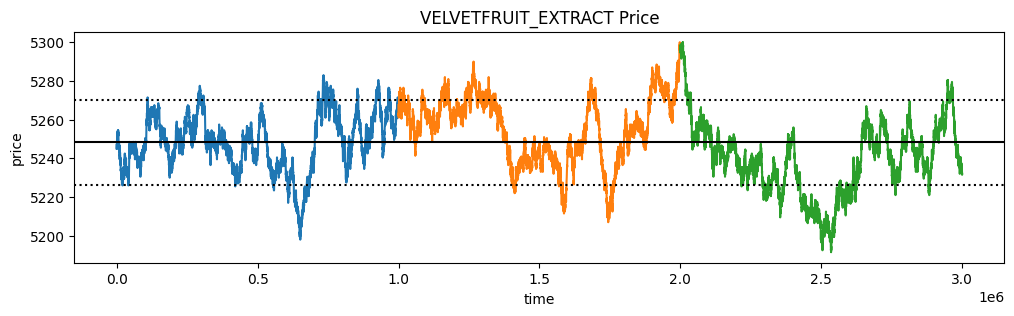

In [11]:
plt.figure(figsize=(12, 3))
plt.plot(price_velvet['timestamp'], price_velvet['mid_price'])
plt.plot(price_velvet_1['timestamp'] + 1000000, price_velvet_1['mid_price'])
plt.plot(price_velvet_2['timestamp'] + 2000000, price_velvet_2['mid_price'])
plt.axhline(price_velvet['mid_price'].mean(), c='k')
plt.axhline(price_velvet['mid_price'].mean() + 1.5 * price_velvet['mid_price'].std(), c='k', linestyle='dotted')
plt.axhline(price_velvet['mid_price'].mean() - 1.5 * price_velvet['mid_price'].std(), c='k', linestyle='dotted')
plt.title('VELVETFRUIT_EXTRACT Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

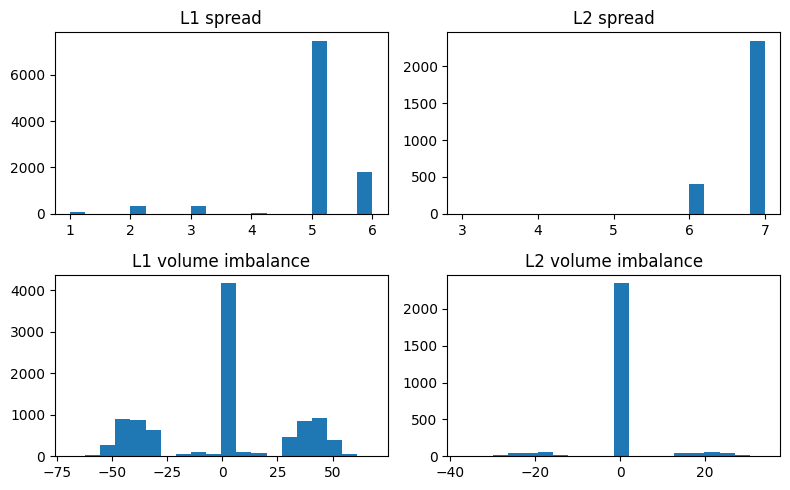

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_velvet['ask_price_1'] - price_velvet['bid_price_1'], bins=20)
ax[0, 1].hist(price_velvet['ask_price_2'] - price_velvet['bid_price_2'], bins=20)
ax[1, 0].hist(price_velvet['ask_volume_1'] - price_velvet['bid_volume_1'], bins=20)
ax[1, 1].hist(price_velvet['ask_volume_2'] - price_velvet['bid_volume_2'], bins=20)
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

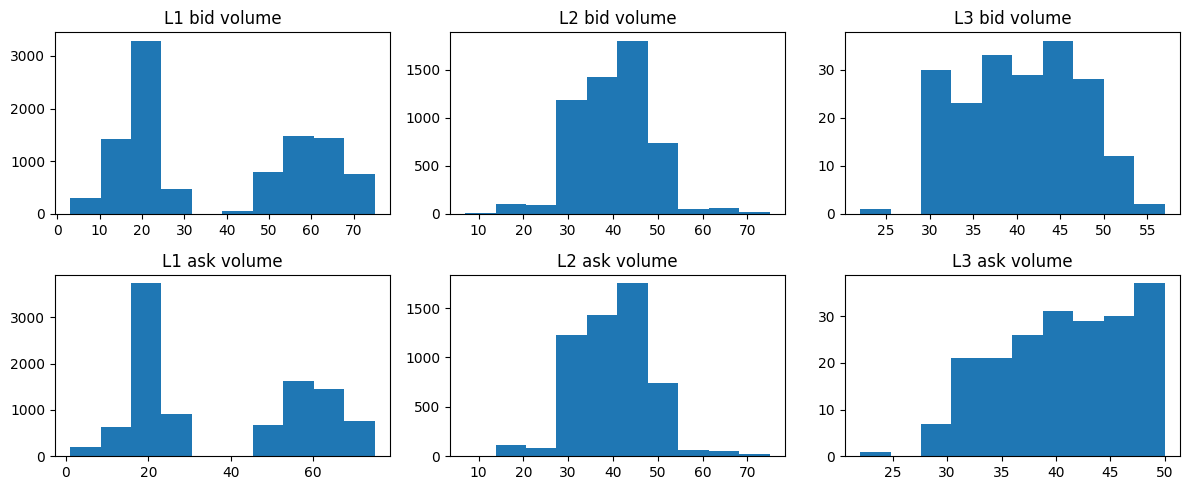

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_velvet['bid_volume_1'])
ax[0, 1].hist(price_velvet['bid_volume_2'])
ax[0, 2].hist(price_velvet['bid_volume_3'])
ax[1, 0].hist(price_velvet['ask_volume_1'])
ax[1, 1].hist(price_velvet['ask_volume_2'])
ax[1, 2].hist(price_velvet['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [14]:
price_velvet = price_velvet.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=30))
price_velvet_1 = price_velvet_1.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=30))
price_velvet_2 = price_velvet_2.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=30))

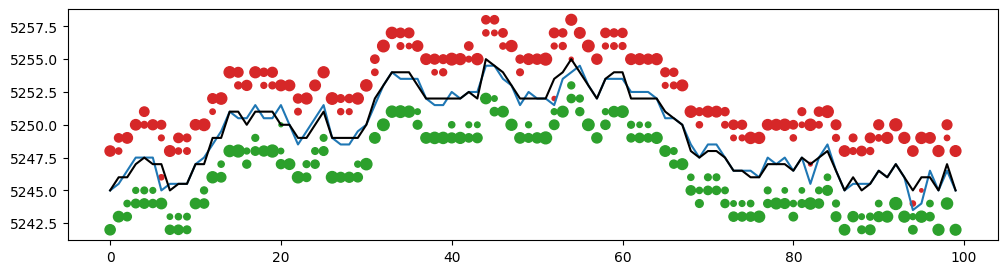

In [15]:
l = 100
plt.figure(figsize=(12, 3))
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['bid_price_1'], s=price_velvet.iloc[:l]['bid_volume_1'], c='tab:green')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['bid_price_2'], s=price_velvet.iloc[:l]['bid_volume_2'], c='tab:green')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['bid_price_3'], s=price_velvet.iloc[:l]['bid_volume_3'], c='tab:green')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['ask_price_1'], s=price_velvet.iloc[:l]['ask_volume_1'], c='tab:red')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['ask_price_2'], s=price_velvet.iloc[:l]['ask_volume_2'], c='tab:red')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['ask_price_3'], s=price_velvet.iloc[:l]['ask_volume_3'], c='tab:red')
plt.plot(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['mid_price'])
plt.plot(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['filtered_mid'], c='k')
plt.show()

In [16]:
print(price_velvet['filtered_mid'].mean(), price_velvet_1['filtered_mid'].mean(), price_velvet_2['filtered_mid'].mean())
print(pd.concat([price_velvet['filtered_mid'], price_velvet_1['filtered_mid'], price_velvet_2['filtered_mid']]).reset_index(drop=True).mean())
print(price_velvet['filtered_mid'].std(), price_velvet_1['filtered_mid'].std(), price_velvet_2['filtered_mid'].std())
print(pd.concat([price_velvet['filtered_mid'], price_velvet_1['filtered_mid'], price_velvet_2['filtered_mid']]).reset_index(drop=True).std())

5248.41445 5255.4089 5239.1803
5247.6678833333335
14.615682263045452 16.984781395999978 18.59161657120416
18.07592177874554


In [17]:
velvet_mean = 5248
velvet_std = 18

In [18]:
price_velvet = price_velvet.set_index('timestamp', drop=True)
price_velvet_1 = price_velvet_1.set_index('timestamp', drop=True)
price_velvet_2 = price_velvet_2.set_index('timestamp', drop=True)

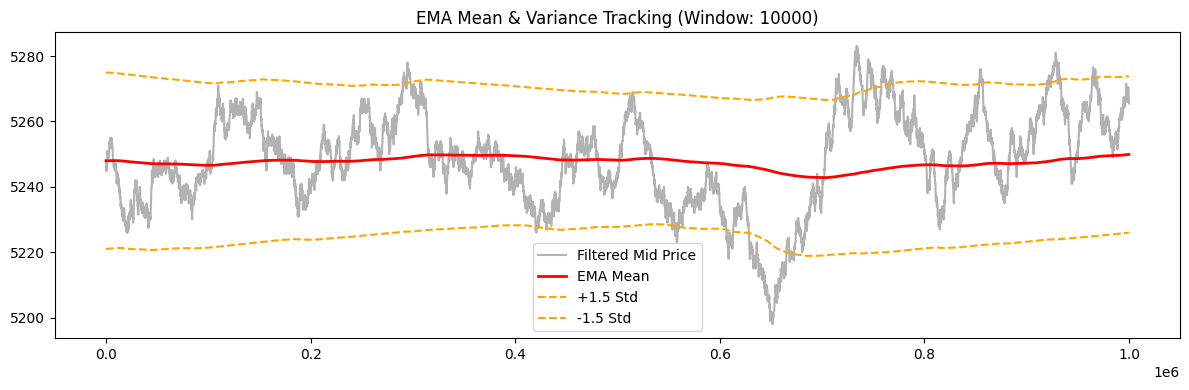

In [19]:
# 1. Initial States (Historical Hardcoded Values)
ema_mean = velvet_mean
ema_var = velvet_std ** 2

# 2. The Tuning Parameter (Equivalent to Q in the Kalman Filter)
# A smaller window adapts faster to regime shifts but is noisier.
# A larger window is more stubborn but slower to catch up to big moves.
window_size = 10000
alpha = 2 / (window_size + 1)

estimated_means = []
estimated_stds = []

# 3. EMA Updating Loop
for price in price_velvet['filtered_mid']:
    # Calculate difference from the *old* mean
    diff = price - ema_mean
    
    # Update Variance FIRST (Mathematically requires the difference from the old mean)
    ema_var = (1 - alpha) * ema_var + alpha * (diff ** 2)
    
    # Update Mean SECOND
    ema_mean = ema_mean + (alpha * diff)
    
    # Calculate instantaneous dynamic standard deviation
    current_std = math.sqrt(ema_var)
    
    estimated_means.append(ema_mean)
    estimated_stds.append(current_std)

# 4. Save to DataFrame
price_velvet['estimated_mean'] = estimated_means
price_velvet['estimated_std'] = estimated_stds

# 5. Plotting (With your exact 1.5 Std Dev bands)
plt.figure(figsize=(12, 4))
plt.plot(price_velvet['filtered_mid'], label='Filtered Mid Price', color='gray', alpha=0.6)
plt.plot(price_velvet['estimated_mean'], label='EMA Mean', color='red', linewidth=2)
plt.plot(price_velvet['estimated_mean'] + 1.5 * price_velvet['estimated_std'], color='orange', linestyle='--', label='+1.5 Std')
plt.plot(price_velvet['estimated_mean'] - 1.5 * price_velvet['estimated_std'], color='orange', linestyle='--', label='-1.5 Std')

plt.title(f'EMA Mean & Variance Tracking (Window: {window_size})')
plt.legend()
plt.tight_layout()
plt.show()

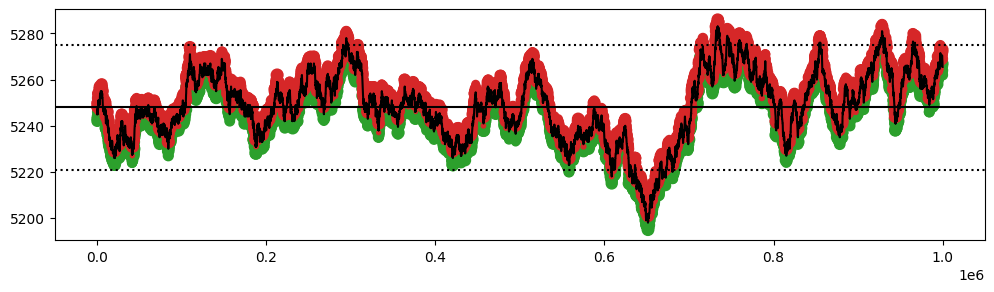

In [20]:
plt.figure(figsize=(12, 3))
plt.scatter(price_velvet.index, price_velvet['bid_price_1'], s=price_velvet['bid_volume_1'], c='tab:green')
plt.scatter(price_velvet.index, price_velvet['bid_price_2'], s=price_velvet['bid_volume_2'], c='tab:green')
plt.scatter(price_velvet.index, price_velvet['bid_price_3'], s=price_velvet['bid_volume_3'], c='tab:green')
plt.scatter(price_velvet.index, price_velvet['ask_price_1'], s=price_velvet['ask_volume_1'], c='tab:red')
plt.scatter(price_velvet.index, price_velvet['ask_price_2'], s=price_velvet['ask_volume_2'], c='tab:red')
plt.scatter(price_velvet.index, price_velvet['ask_price_3'], s=price_velvet['ask_volume_3'], c='tab:red')
plt.plot(price_velvet['filtered_mid'], c='k')
plt.axhline(velvet_mean, c='k')
plt.axhline(velvet_mean + 1.5 * velvet_std, c='k', linestyle='dotted')
plt.axhline(velvet_mean - 1.5 * velvet_std, c='k', linestyle='dotted')
plt.show()

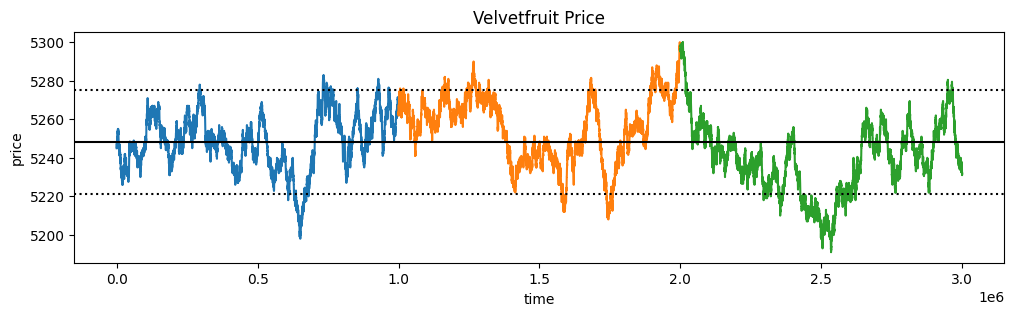

In [21]:
plt.figure(figsize=(12, 3))
plt.plot(price_velvet.index, price_velvet['filtered_mid'])
plt.plot(price_velvet_1.index + 1000000, price_velvet_1['filtered_mid'])
plt.plot(price_velvet_2.index + 2000000, price_velvet_2['filtered_mid'])
plt.axhline(velvet_mean, c='k')
plt.axhline(velvet_mean + 1.5 * velvet_std, c='k', linestyle='dotted')
plt.axhline(velvet_mean - 1.5 * velvet_std, c='k', linestyle='dotted')
plt.title('Velvetfruit Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [22]:
train_logr = np.log(price_velvet['filtered_mid']).diff().dropna()
test_logr = np.log(price_velvet_1['filtered_mid']).diff().dropna()

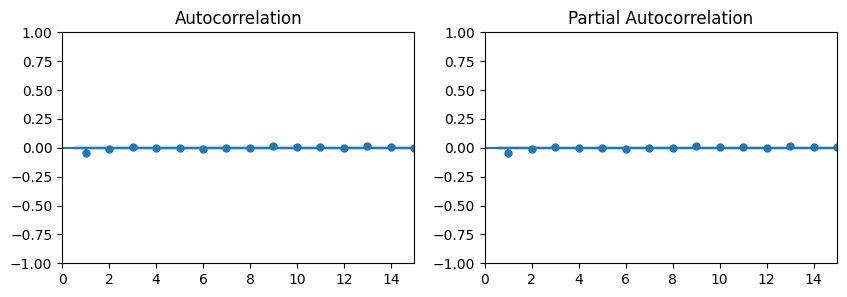

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [24]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

      lb_stat  lb_pvalue
10  27.240307   0.002386
Reject null hypothesis: data is not white noise.


In [25]:
true = test_logr[1:].to_numpy()

In [26]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.0002709730503440374


In [27]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.05, b = 0.0
AR(1) RMSE: 0.00018757482010207068


In [28]:
spread = (price_velvet['ask_price_1'] - price_velvet['bid_price_1']).median()
vol = price_velvet['mid_price'].std()
print("Velvet spread and daily std:")
print(f"{spread}, {vol}")

Velvet spread and daily std:
5.0, 14.61436185220671


# VEV

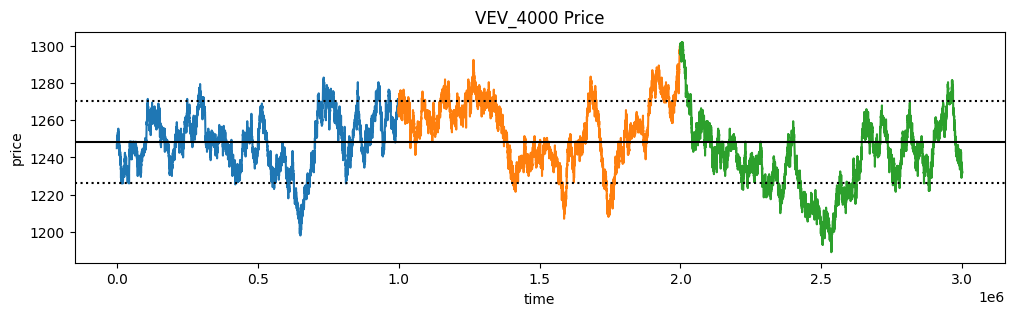

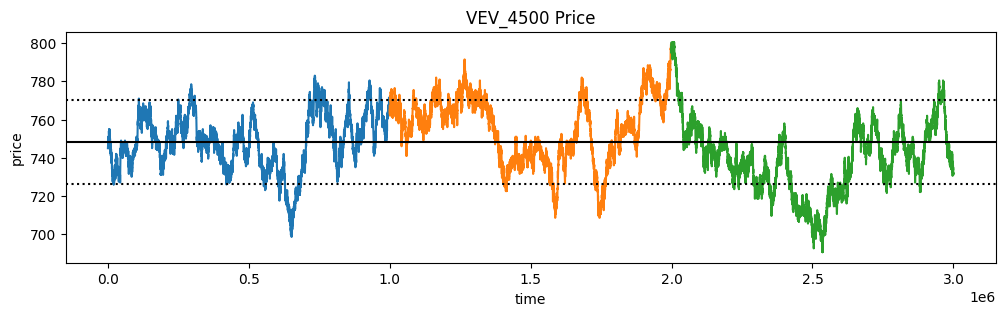

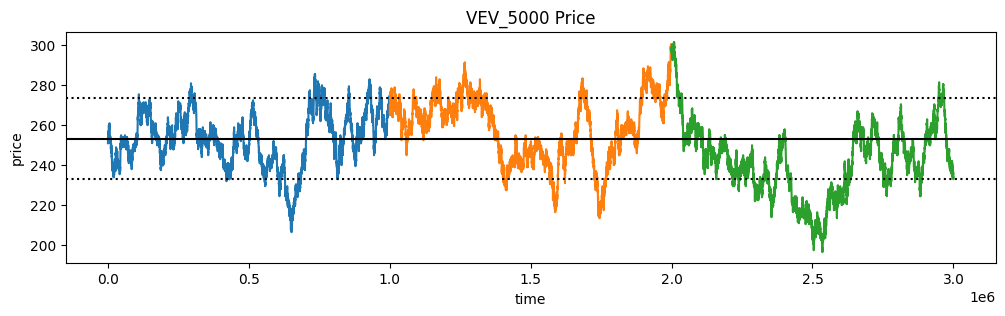

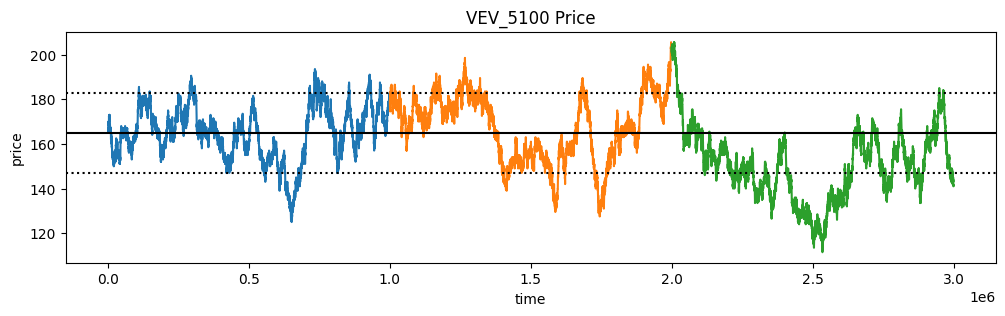

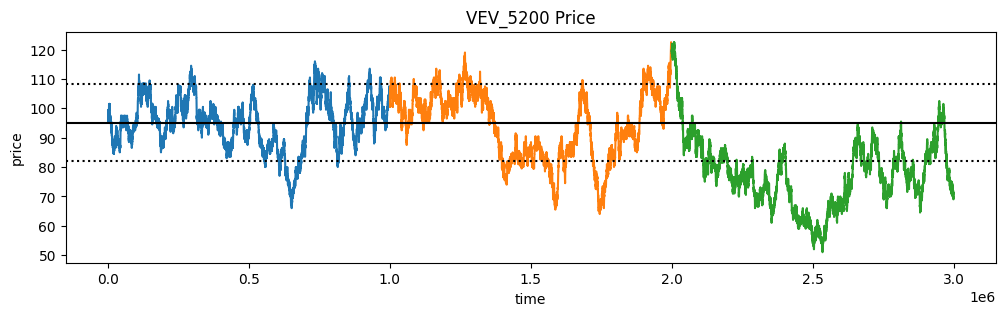

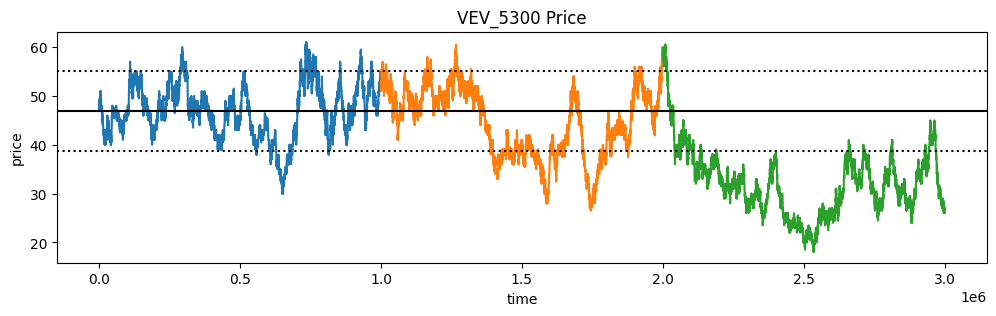

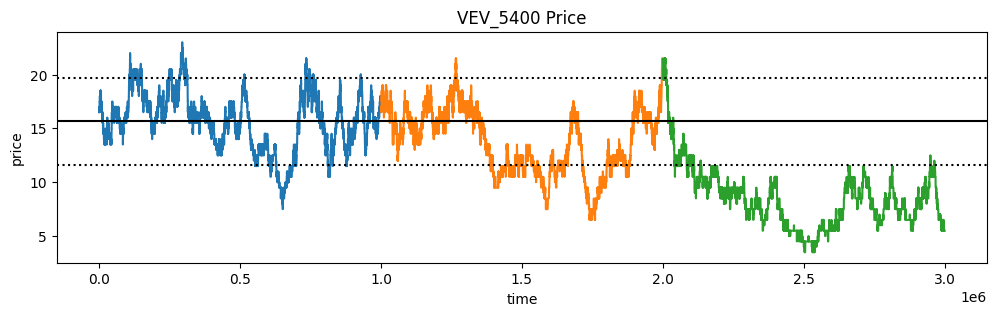

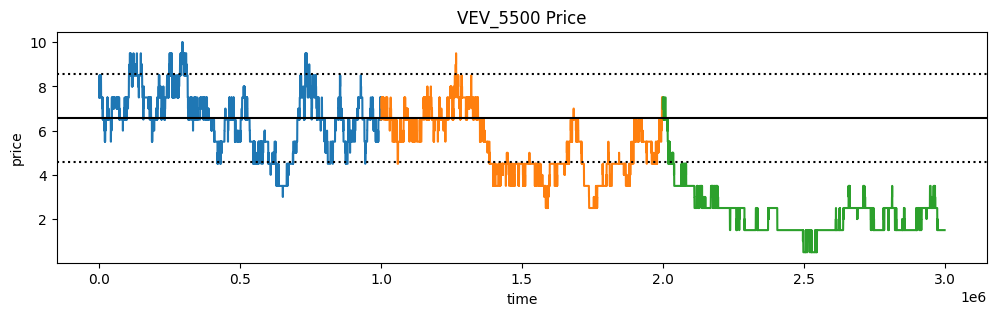

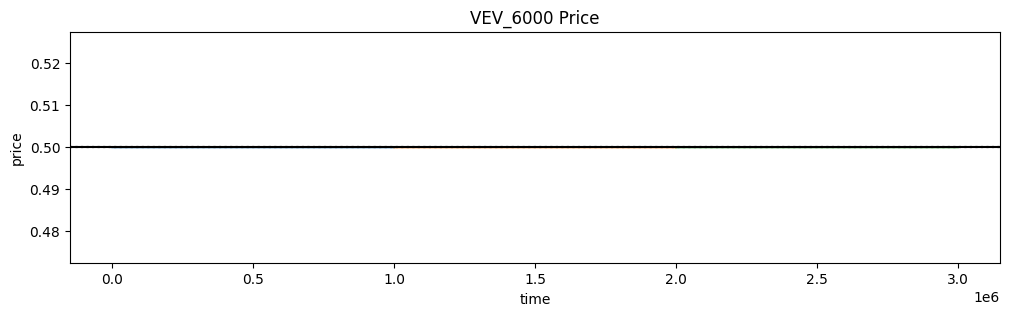

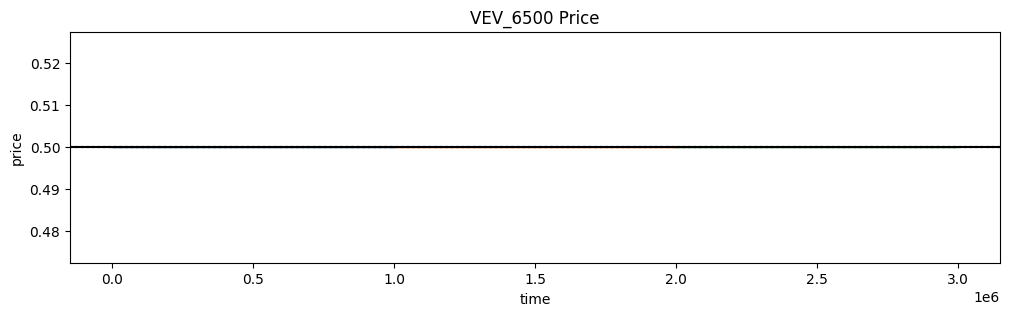

In [30]:
for strike in strikes:
    plt.figure(figsize=(12, 3))
    plt.plot(price_vev[strike]['timestamp'], price_vev[strike]['mid_price'])
    plt.plot(price_vev_1[strike]['timestamp'] + 1000000, price_vev_1[strike]['mid_price'])
    plt.plot(price_vev_2[strike]['timestamp'] + 2000000, price_vev_2[strike]['mid_price'])
    plt.axhline(price_vev[strike]['mid_price'].mean(), c='k')
    plt.axhline(price_vev[strike]['mid_price'].mean() + 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.axhline(price_vev[strike]['mid_price'].mean() - 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.title(f'VEV_{strike} Price')
    plt.xlabel('time')
    plt.ylabel('price')
    plt.show()

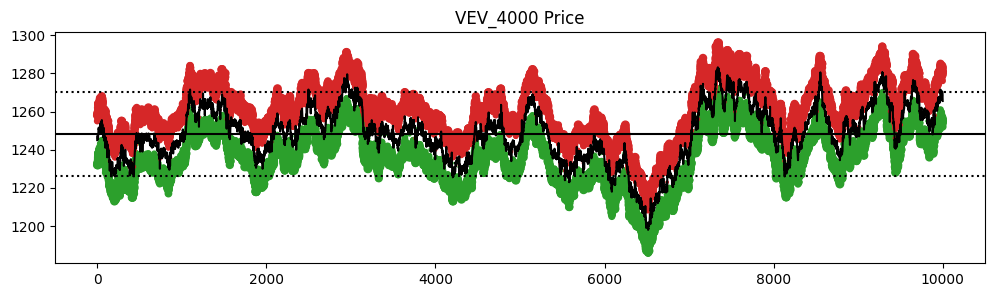

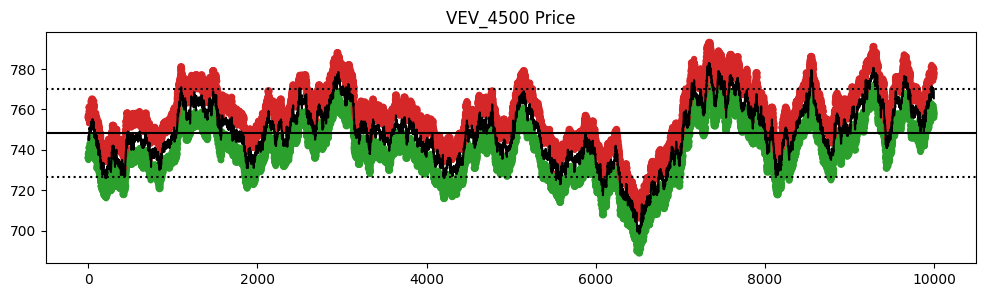

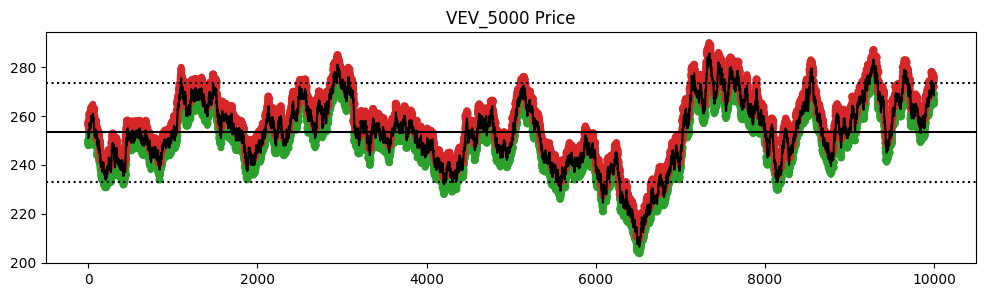

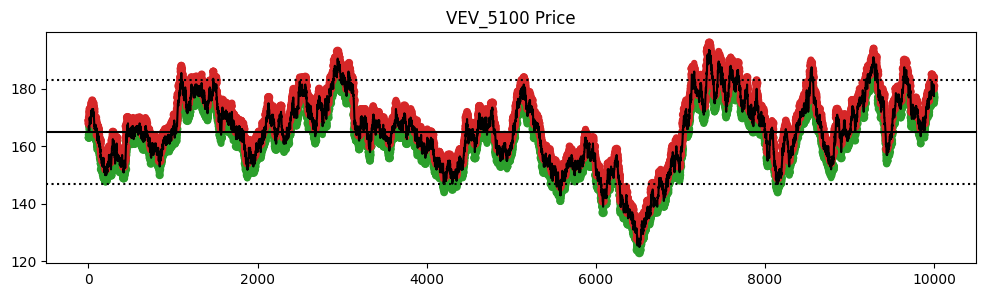

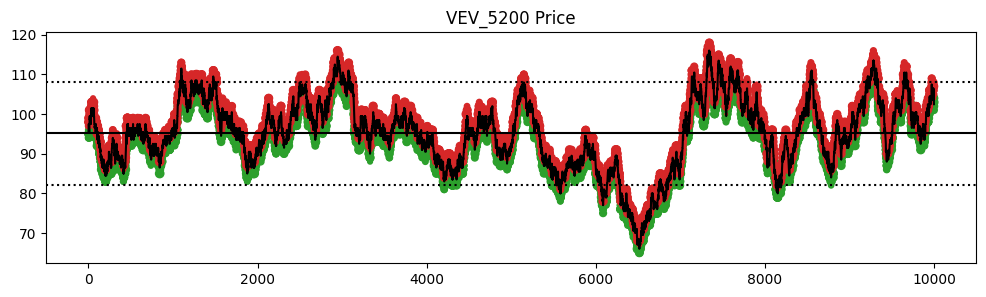

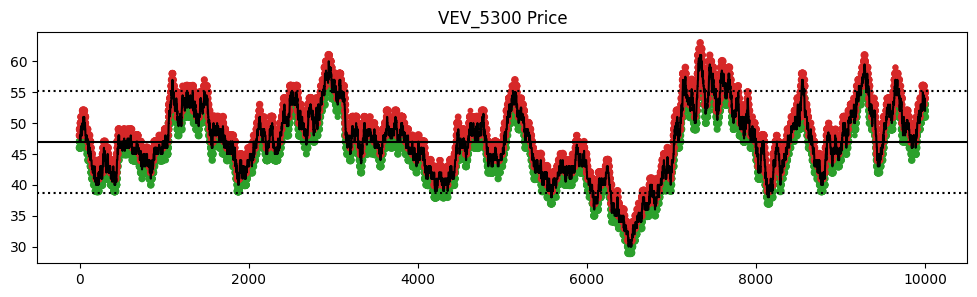

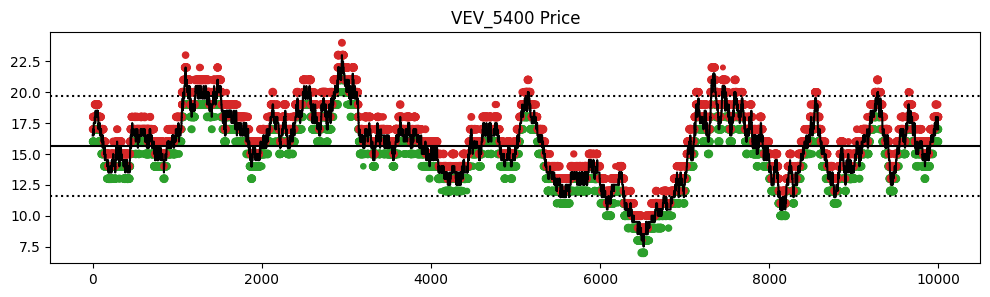

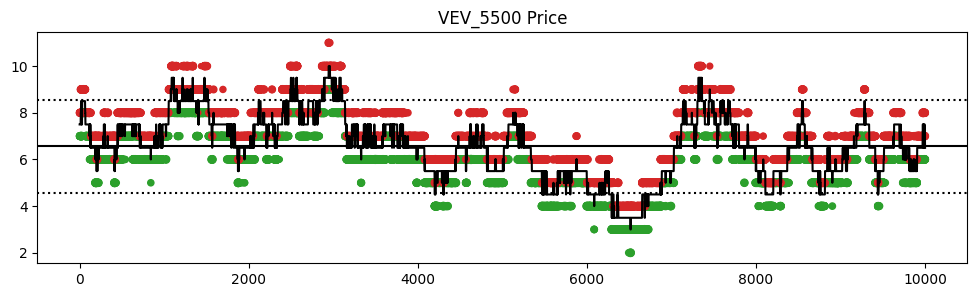

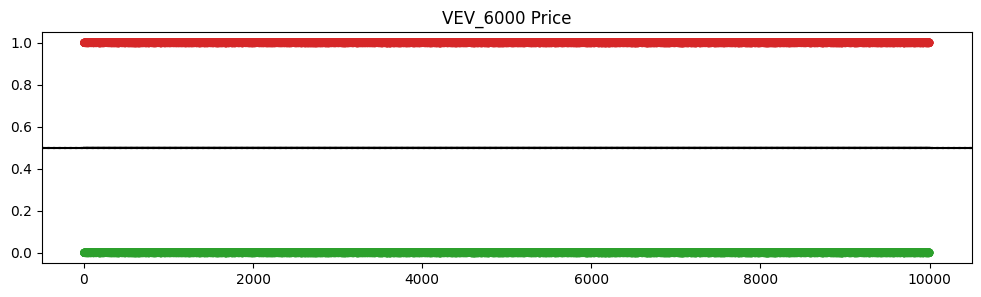

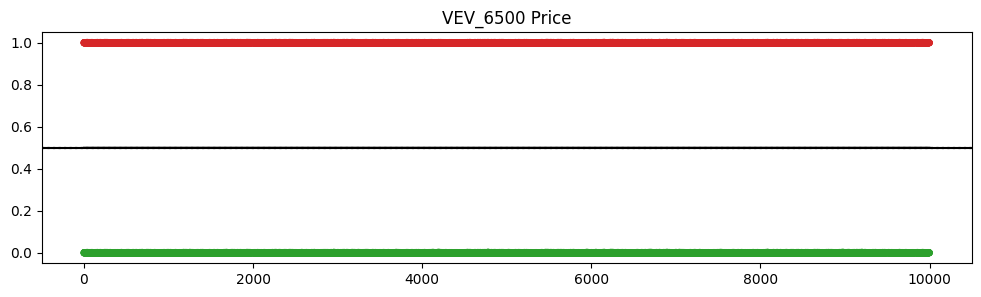

In [31]:
for strike in strikes:
    plt.figure(figsize=(12, 3))
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['bid_price_1'], s=price_vev[strike]['bid_volume_1'], c='tab:green')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['bid_price_2'], s=price_vev[strike]['bid_volume_2'], c='tab:green')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['bid_price_3'], s=price_vev[strike]['bid_volume_3'], c='tab:green')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['ask_price_1'], s=price_vev[strike]['ask_volume_1'], c='tab:red')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['ask_price_2'], s=price_vev[strike]['ask_volume_2'], c='tab:red')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['ask_price_3'], s=price_vev[strike]['ask_volume_3'], c='tab:red')
    plt.plot(price_vev[strike]['timestamp']//100, price_vev[strike]['mid_price'], c='k')
    plt.axhline(price_vev[strike]['mid_price'].mean(), c='k')
    plt.axhline(price_vev[strike]['mid_price'].mean() + 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.axhline(price_vev[strike]['mid_price'].mean() - 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.title(f'VEV_{strike} Price')
    plt.show()

In [32]:
selected_strikes = strikes[:6]

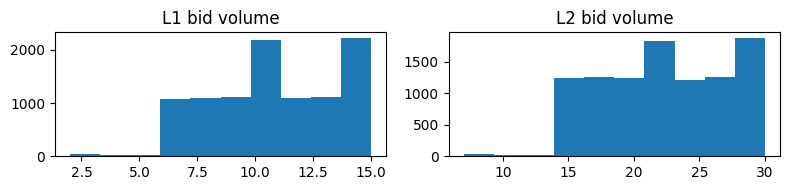

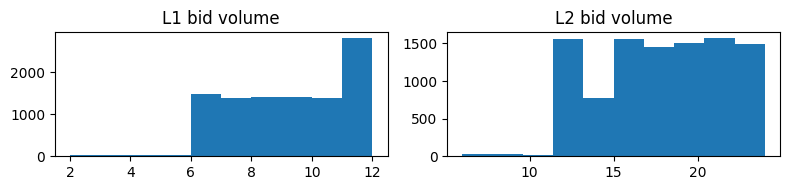

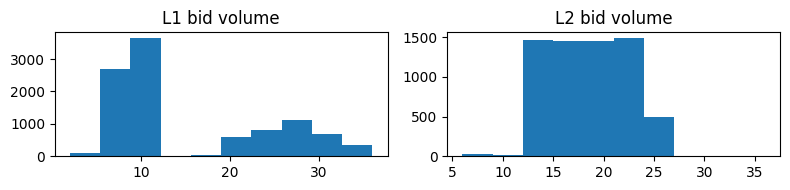

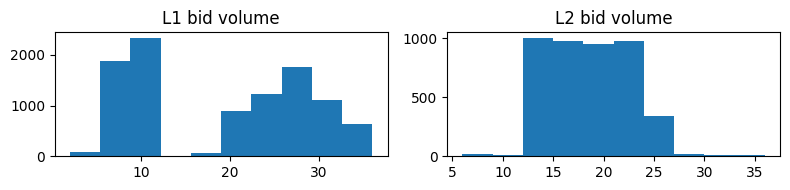

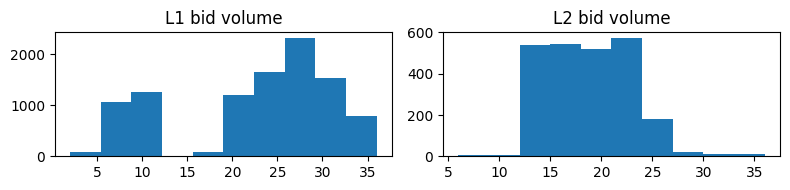

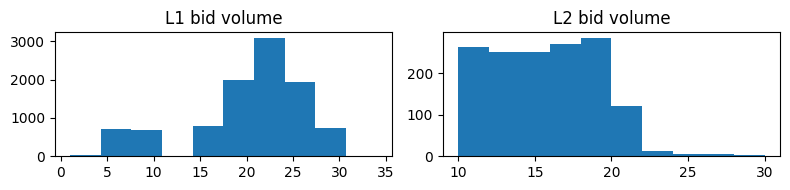

In [33]:
for strike in selected_strikes:
    fig, ax = plt.subplots(1, 2, figsize=(8, 2))
    ax[0].hist(price_vev[strike]['bid_volume_1'])
    ax[1].hist(price_vev[strike]['bid_volume_2'])
    ax[0].set_title('L1 bid volume')
    ax[1].set_title('L2 bid volume')
    plt.tight_layout()
    plt.show()

In [34]:
for strike in selected_strikes:
    price_vev[strike] = price_vev[strike].assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))
    price_vev_1[strike] = price_vev_1[strike].assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))
    price_vev_2[strike] = price_vev_2[strike].assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))

In [35]:
print(f"{"strike":<10} {"spread":<10} {"p_mean":<10} {"p_std":<10}")
for strike in selected_strikes:
    spread = (price_vev[strike]['ask_price_1'] - price_vev[strike]['bid_price_1']).median()
    p_mean = round(pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])['filtered_mid'].mean())
    p_std = round(pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])['filtered_mid'].std())
    print(f"{strike:<10} {spread:<10} {p_mean:<10} {p_std:<10}")

strike     spread     p_mean     p_std     
4000       21.0       1248       18        
4500       16.0       748        18        
5000       6.0        251        17        
5100       4.0        161        16        
5200       3.0        89         13        
5300       2.0        41         9         


In [36]:
for strike in selected_strikes:
    print(f'Strike: {strike}')
    train_logr = np.log(price_vev[strike]['filtered_mid']).diff().dropna()
    test_logr = np.log(price_vev_1[strike]['filtered_mid']).diff().dropna()
    
    true = test_logr[1:].to_numpy()
    
    # Naive
    pred = test_logr[:-1].to_numpy()
    err = true - pred
    rmse = np.mean(err ** 2) ** 0.5
    print(f'Naive RMSE: {rmse}')
    
    # AR(1)
    coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
    a, b = coeffs
    print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')
    
    pred = test_logr[:-1].to_numpy() * a
    err = true - pred
    rmse = np.mean(err ** 2) ** 0.5
    print(f'AR(1) RMSE: {rmse}')
    print()

Strike: 4000
Naive RMSE: 0.0011370803127021079
Params: a = -0.06, b = 0.0
AR(1) RMSE: 0.0007863594377750888

Strike: 4500
Naive RMSE: 0.001886558534050746
Params: a = -0.05, b = 0.0
AR(1) RMSE: 0.001304471195754418

Strike: 5000
Naive RMSE: 0.005344969758189233
Params: a = -0.07, b = 0.0
AR(1) RMSE: 0.0036823130862599003

Strike: 5100
Naive RMSE: 0.0074189701182675455
Params: a = -0.07, b = 0.0
AR(1) RMSE: 0.005115036771463116

Strike: 5200
Naive RMSE: 0.01070336401808428
Params: a = -0.1, b = 0.0
AR(1) RMSE: 0.007216035069618001

Strike: 5300
Naive RMSE: 0.016556635805567682
Params: a = -0.16, b = 0.0
AR(1) RMSE: 0.010593498596793137



# Options

In [25]:
for strike in strikes:
    price_vev[strike]['spot'] = price_velvet['filtered_mid']
    price_vev[strike]['intrinsic'] = np.max([price_vev[strike]['spot'] - price_vev[strike]['strike'], np.zeros(price_vev[strike].shape[0])], axis=0)
    price_vev[strike]['filtered_mid'] = price_vev[strike].apply(lambda x: x['intrinsic'] if x['mid_price'] < x['intrinsic'] else x['mid_price'], axis=1)
    price_vev[strike]['implied_vol'] = price_vev[strike].apply(calc_implied_vol, axis=1)

    price_vev[strike]['vega'] = price_vev[strike].apply(calc_vega, axis=1)
    price_vev[strike]['implied_vol'] = price_vev[strike].apply(lambda x: x['implied_vol'] if x['vega'] > 1e-6 else None, axis=1)  # filter 0 vega
    
    price_vev[strike]['delta'] = price_vev[strike].apply(calc_delta, axis=1)
    price_vev[strike]['gamma'] = price_vev[strike].apply(calc_gamma, axis=1)
    price_vev[strike]['vega'] = price_vev[strike].apply(calc_vega, axis=1)

    price_vev[strike]['moneyness'] = price_vev[strike].apply(calc_moneyness, axis=1)

In [26]:
for strike in strikes:
    price_vev_1[strike]['spot'] = price_velvet_1['filtered_mid']
    price_vev_1[strike]['intrinsic'] = np.max([price_vev_1[strike]['spot'] - price_vev_1[strike]['strike'], np.zeros(price_vev_1[strike].shape[0])], axis=0)
    price_vev_1[strike]['filtered_mid'] = price_vev_1[strike].apply(lambda x: x['intrinsic'] if x['mid_price'] < x['intrinsic'] else x['mid_price'], axis=1)
    price_vev_1[strike]['implied_vol'] = price_vev_1[strike].apply(calc_implied_vol, axis=1)

    price_vev_1[strike]['vega'] = price_vev_1[strike].apply(calc_vega, axis=1)
    price_vev_1[strike]['implied_vol'] = price_vev_1[strike].apply(lambda x: x['implied_vol'] if x['vega'] > 1e-6 else None, axis=1)  # filter 0 vega
    
    price_vev_1[strike]['delta'] = price_vev_1[strike].apply(calc_delta, axis=1)
    price_vev_1[strike]['gamma'] = price_vev_1[strike].apply(calc_gamma, axis=1)
    price_vev_1[strike]['vega'] = price_vev_1[strike].apply(calc_vega, axis=1)

    price_vev_1[strike]['moneyness'] = price_vev_1[strike].apply(calc_moneyness, axis=1)

In [27]:
for strike in strikes:
    price_vev_2[strike]['spot'] = price_velvet_2['filtered_mid']
    price_vev_2[strike]['intrinsic'] = np.max([price_vev_2[strike]['spot'] - price_vev_2[strike]['strike'], np.zeros(price_vev_2[strike].shape[0])], axis=0)
    price_vev_2[strike]['filtered_mid'] = price_vev_2[strike].apply(lambda x: x['intrinsic'] if x['mid_price'] < x['intrinsic'] else x['mid_price'], axis=1)
    price_vev_2[strike]['implied_vol'] = price_vev_2[strike].apply(calc_implied_vol, axis=1)

    price_vev_2[strike]['vega'] = price_vev_2[strike].apply(calc_vega, axis=1)
    price_vev_2[strike]['implied_vol'] = price_vev_2[strike].apply(lambda x: x['implied_vol'] if x['vega'] > 1e-6 else None, axis=1)  # filter 0 vega
    
    price_vev_2[strike]['delta'] = price_vev_2[strike].apply(calc_delta, axis=1)
    price_vev_2[strike]['gamma'] = price_vev_2[strike].apply(calc_gamma, axis=1)
    price_vev_2[strike]['vega'] = price_vev_2[strike].apply(calc_vega, axis=1)

    price_vev_2[strike]['moneyness'] = price_vev_2[strike].apply(calc_moneyness, axis=1)

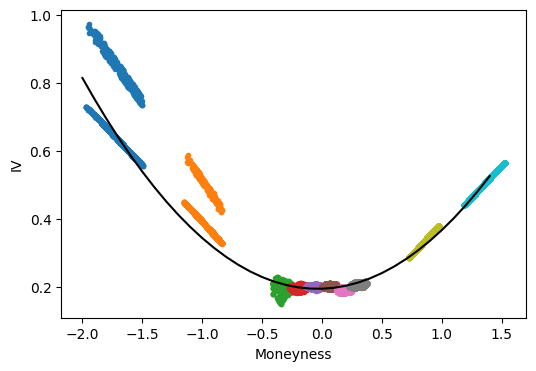

In [28]:
m_list, v_list = [], []
for strike in strikes:
    m_list.extend(list(price_vev[strike][price_vev[strike]['implied_vol'].notna()]['moneyness'].to_numpy()))
    v_list.extend(list(price_vev[strike][price_vev[strike]['implied_vol'].notna()]['implied_vol'].to_numpy()))
    m_list.extend(list(price_vev_1[strike][price_vev_1[strike]['implied_vol'].notna()]['moneyness'].to_numpy()))
    v_list.extend(list(price_vev_1[strike][price_vev_1[strike]['implied_vol'].notna()]['implied_vol'].to_numpy()))
    m_list.extend(list(price_vev_2[strike][price_vev_2[strike]['implied_vol'].notna()]['moneyness'].to_numpy()))
    v_list.extend(list(price_vev_2[strike][price_vev_2[strike]['implied_vol'].notna()]['implied_vol'].to_numpy()))

a, b, c = np.polyfit(m_list, v_list, 2)
modelled = a * (np.arange(-20, 15) / 10) ** 2 + b * np.arange(-20, 15) / 10 + c

plt.figure(figsize=(6, 4))
for strike in strikes:
    df = pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])
    plt.scatter(df['moneyness'], df['implied_vol'], marker='.')
plt.plot(np.arange(-20, 15) / 10, modelled, c='k')
plt.xlabel('Moneyness')
plt.ylabel('IV')
plt.show()

In [29]:
print(a, b, c)

0.16082565883588573 0.011712929482911333 0.19478728225341402


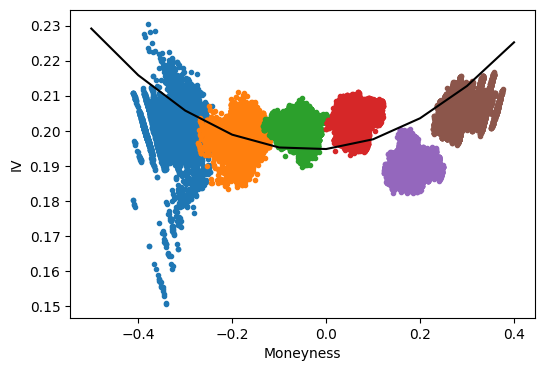

In [30]:
modelled = a * (np.arange(-5, 5) / 10) ** 2 + b * np.arange(-5, 5) / 10 + c

plt.figure(figsize=(6, 4))
for strike in atm_strikes:
    df = pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])
    plt.scatter(df['moneyness'], df['implied_vol'], marker='.')
plt.plot(np.arange(-5, 5) / 10, modelled, c='k')
plt.xlabel('Moneyness')
plt.ylabel('IV')
plt.show()